In [35]:
# 安装所需的 Python 包（使用清华镜像源加速）
import subprocess, sys
subprocess.check_call(
    [sys.executable, '-m', 'pip', 'install', 'scipy', 'pandas',
     '-i', 'https://pypi.tuna.tsinghua.edu.cn/simple']
)
print("所有依赖包安装完成！")


所有依赖包安装完成！


In [36]:
# === 全局设置：matplotlib 中文字体配置 ===
import matplotlib.pyplot as plt
import matplotlib

for fn in ["Microsoft YaHei", "SimHei", "DengXian"]:
    try:
        matplotlib.font_manager.findfont(fn, fallback_to_default=False)
        plt.rcParams['font.sans-serif'] = [fn] + plt.rcParams['font.sans-serif']
        break
    except:
        continue

plt.rcParams['axes.unicode_minus'] = False
print("当前中文字体:", plt.rcParams["font.sans-serif"][0])


当前中文字体: Microsoft YaHei


# 第 2 章 抽样分布与统计量


> **本章导读**:第 1 章定义了什么是「样本」.那么样本的函数 --  -- 统计量 --  -- 服从什么分布?这就是「抽样分布」要回答的问题.本章从正态分布的可加性出发,系统地导出三大抽样分布($\chi^2$、$t$、$F$),进而讨论指数族、充分统计量和完备统计量等核心概念.这些是参数估计和假设检验的数学基础.


---


## 2.1 抽样分布


### 2.1.1 正态分布的可加性


> **定理**:若 $X_1,X_2,\cdots,X_n$ 相互独立且 $X_i\sim N(\mu_i,\sigma_i^2)$,则它们的线性组合仍服从正态分布:


$$\sum_{i=1}^n a_iX_i\sim N\!\left(\sum_{i=1}^n a_i\mu_i,\ \sum_{i=1}^n a_i^2\sigma_i^2\right)$$


**推论**(同分布情形):来自正态总体 $N(\mu,\sigma^2)$ 的样本 $X_1,\cdots,X_n$:


$$\sum_{i=1}^n X_i\sim N(n\mu,\ n\sigma^2),\qquad \overline{X}\sim N\!\left(\mu,\ \frac{\sigma^2}{n}\right)$$


> **💡 直观理解**:正态分布是唯一具有「可加性」的常见分布 --  -- 独立正态变量之和仍然是正态的.这一性质使正态分布在统计学中具有特殊地位.


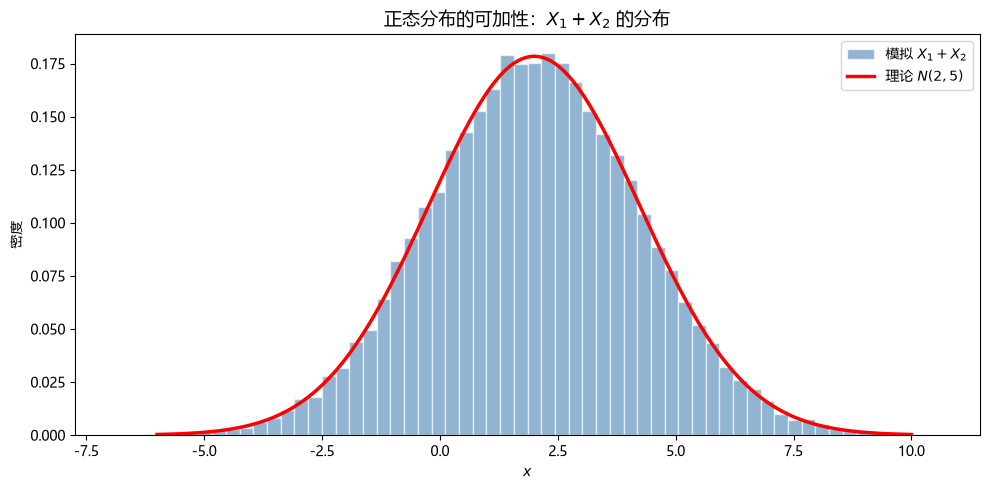

模拟均值: 2.004 (理论: 2)
模拟方差: 4.981 (理论: 5)
✅ 验证了正态分布的可加性。


In [37]:
# === 代码演示：正态分布的可加性 ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# 设 X1 ~ N(0,1), X2 ~ N(2,4), 验证 X1+X2 ~ N(2,5)
n_sim = 50000
X1 = np.random.normal(0, 1, n_sim)
X2 = np.random.normal(2, 2, n_sim)
S = X1 + X2

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(S, bins=60, density=True, alpha=0.6, color='steelblue', edgecolor='white',
        label='模拟 $X_1+X_2$')
x = np.linspace(-6, 10, 300)
ax.plot(x, norm.pdf(x, 2, np.sqrt(5)), 'r-', linewidth=2.5,
        label='理论 $N(2,5)$')
ax.set_title('正态分布的可加性：$X_1+X_2$ 的分布', fontsize=13)
ax.set_xlabel('$x$')
ax.set_ylabel('密度')
ax.legend()
plt.tight_layout()
plt.show()

print(f"模拟均值: {np.mean(S):.3f} (理论: 2)")
print(f"模拟方差: {np.var(S):.3f} (理论: 5)")
print("✅ 验证了正态分布的可加性。")


---


### 2.1.2 二项分布概率的积分表示


对于 $X\sim B(n,p)$,有以下优美的恒等式:


$$\sum_{k=r}^n\binom{n}{k}p^k(1-p)^{n-k}=r\binom{n}{r}\int_0^p t^{r-1}(1-t)^{n-r}\,dt$$


**证明思路**:


1. **左侧求导**,利用组合恒等式 $k\binom{n}{k}=n\binom{n-1}{k-1}$ 和 $(n-k)\binom{n}{k}=n\binom{n-1}{k}$；


2. **哑变量换元**,使求和指标对齐；


3. 两式相减,恰好等于右侧导数 $rI'(p)=r\binom{n}{r}p^{r-1}(1-p)^{n-r}$；


4. 由 **Newton-Leibniz 公式**,积分即得.


In [38]:
# === 代码演示：二项分布概率的积分表示（数值验证）===
import numpy as np
from scipy.stats import binom
from scipy.integrate import quad
from scipy.special import comb

n, r, p = 10, 3, 0.4

# 左侧：累加概率
left_side = binom.sf(r-1, n, p)  # P(X >= r)
print(f"n={n}, r={r}, p={p}")
print(f"左侧: P(X>={r}) = {left_side:.6f}")

# 右侧：积分
def integrand(t):
    return t**(r-1) * (1-t)**(n-r)
integral, _ = quad(integrand, 0, p)
right_side = r * comb(n, r) * integral
print(f"右侧: r*C(n,r)*int = {right_side:.6f}")
print(f"偏差: {abs(left_side - right_side):.2e}")
print("✅ 恒等式成立！")


n=10, r=3, p=0.4
左侧: P(X>=3) = 0.832710
右侧: r*C(n,r)*int = 0.832710
偏差: 0.00e+00
✅ 恒等式成立！


---


### 2.1.3 顺序统计量


#### 定义


将样本 $X_1,\cdots,X_n$ 按从小到大的顺序排列:


$$X_{(1)}\le X_{(2)}\le\cdots\le X_{(n)}$$


称 $X_{(k)}$ 为 **第 $k$ 个顺序统计量**(order statistic).特别地:


- $X_{(1)}=\min\{X_1,\cdots,X_n\}$  --  --  样本最小值


- $X_{(n)}=\max\{X_1,\cdots,X_n\}$  --  --  样本最大值


> **💡 直观理解**:顺序统计量保留了样本的「次序信息」,这在许多非参数方法中至关重要.


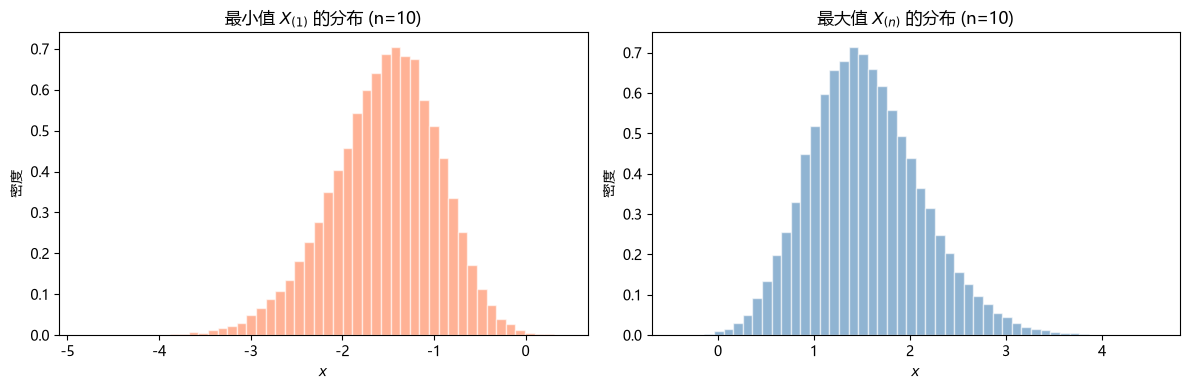

X_(1) 的模拟均值: -1.540
X_(n) 的模拟均值: 1.537


In [39]:
# === 代码演示：顺序统计量的模拟 ===
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n, n_sim = 10, 50000
X1_samples = np.zeros(n_sim)
Xn_samples = np.zeros(n_sim)

for i in range(n_sim):
    sample = np.random.normal(0, 1, n)
    X1_samples[i] = np.min(sample)
    Xn_samples[i] = np.max(sample)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X1_samples, bins=50, density=True, alpha=0.6, color='coral', edgecolor='white')
axes[0].set_title('最小值 $X_{(1)}$ 的分布 (n=10)', fontsize=12)
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('密度')

axes[1].hist(Xn_samples, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='white')
axes[1].set_title('最大值 $X_{(n)}$ 的分布 (n=10)', fontsize=12)
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('密度')

plt.tight_layout()
plt.show()

print(f"X_(1) 的模拟均值: {np.mean(X1_samples):.3f}")
print(f"X_(n) 的模拟均值: {np.mean(Xn_samples):.3f}")


#### 分布函数与密度函数


利用 **独立性** 和 **同分布** 性质:


$$\begin{aligned}F_{X_{(1)}}(x) &= 1-P\{X_1>x,\cdots,X_n>x\}= 1-(1-F(x))^n \\[4pt]F_{X_{(n)}}(x) &= P\{X_1\le x,\cdots,X_n\le x\}= F(x)^n\end{aligned}$$


求导得密度函数:


$$\begin{aligned}f_{X_{(1)}}(x) &= n\,(1-F(x))^{\,n-1}f(x) \\[4pt]f_{X_{(n)}}(x) &= n\,F^{\,n-1}(x)f(x)\end{aligned}$$


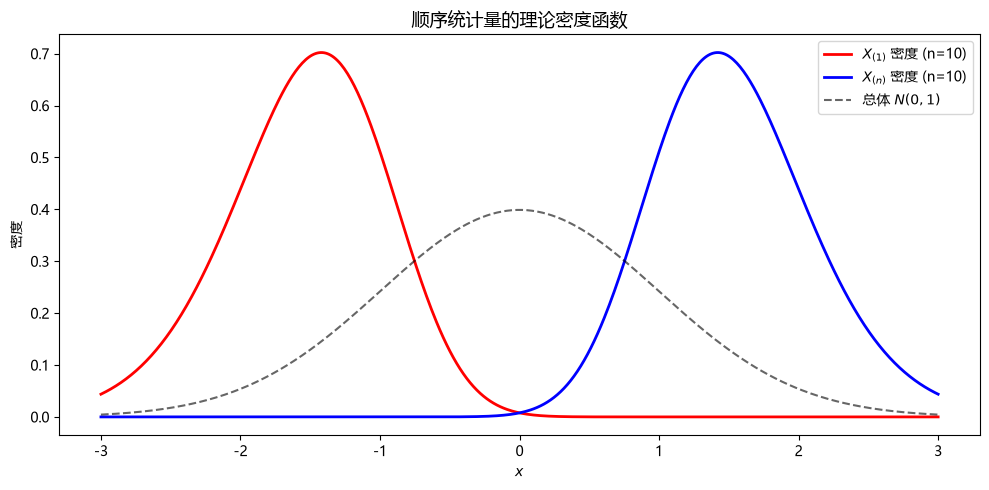

观察: 最小值分布左偏，最大值分布右偏。


In [40]:
# === 代码演示：顺序统计量的理论密度曲线 ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

n = 10
x = np.linspace(-3, 3, 500)
F = norm.cdf(x)
f = norm.pdf(x)

f_min = n * (1 - F)**(n-1) * f
f_max = n * F**(n-1) * f

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, f_min, 'r-', linewidth=2, label=f'$X_{{(1)}}$ 密度 (n={n})')
ax.plot(x, f_max, 'b-', linewidth=2, label=f'$X_{{(n)}}$ 密度 (n={n})')
ax.plot(x, f, 'k--', linewidth=1.5, alpha=0.6, label='总体 $N(0,1)$')
ax.set_title('顺序统计量的理论密度函数', fontsize=13)
ax.set_xlabel('$x$')
ax.set_ylabel('密度')
ax.legend()
plt.tight_layout()
plt.show()
print("观察: 最小值分布左偏，最大值分布右偏。")


#### 最小与最大顺序统计量的联合密度


$$f(x_{(1)},x_{(n)})=n(n-1)\bigl(F(x_{(n)})-F(x_{(1)})\bigr)^{\,n-2}f(x_{(1)})f(x_{(n)})$$


> **📌 推导要点**:联合分布函数 $F(x_{(1)},x_{(n)})=F(x_{(n)})^n-(F(x_{(n)})-F(x_{(1)}))^n$,对 $x_{(1)},x_{(n)}$ 求混合偏导即得.


---


#### 示例 1:指数分布 $E(\lambda)$ 的最小顺序统计量


$$F(x)=1-e^{-\lambda x}\quad(x>0)$$


$$\begin{aligned}f_{X_{(1)}}(x) &= n\,(e^{-\lambda x})^{\,n-1}\cdot\lambda e^{-\lambda x}= n\lambda\,e^{-n\lambda x}I_{\{x>0\}}\end{aligned}$$


即 $X_{(1)}\sim E(n\lambda)$,因此:


$$E(X_{(1)})=\frac{1}{n\lambda},\qquad D(X_{(1)})=\frac{1}{n^2\lambda^2}$$


> **💡 直观理解**:$n$ 个指数变量中的最小值,相当于把指数分布的「速率」参数放大了 $n$ 倍,因此期望寿命缩短为原来的 $1/n$.


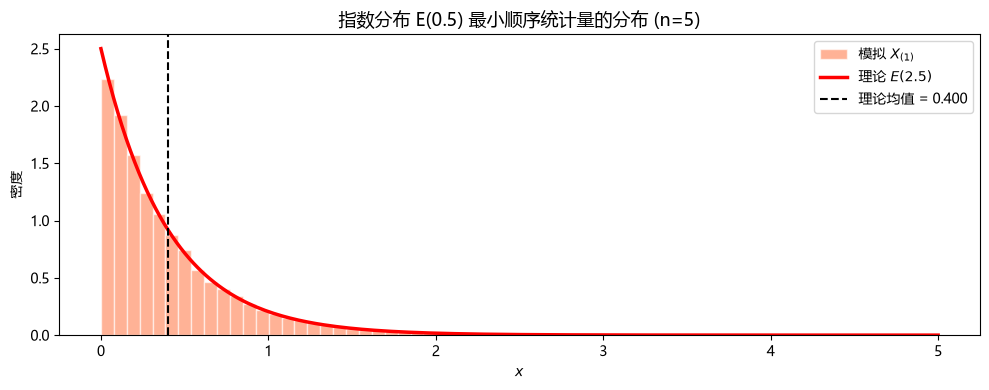

模拟均值: 0.3993 (理论: 0.4000)
✅ 验证了 X_(1) ~ E(n*lambda)


In [41]:
# === 代码演示：指数分布的最小顺序统计量 ===
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

lam = 0.5
n = 5
n_sim = 50000

X1_samples = np.zeros(n_sim)
for i in range(n_sim):
    sample = np.random.exponential(1/lam, n)
    X1_samples[i] = np.min(sample)

theory_mean = 1 / (n * lam)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(X1_samples, bins=60, density=True, alpha=0.6, color='coral', edgecolor='white',
        label='模拟 $X_{(1)}$')
x = np.linspace(0, 5, 200)
ax.plot(x, n*lam * np.exp(-n*lam * x), 'r-', linewidth=2.5,
        label=f'理论 $E({n*lam})$')
ax.axvline(theory_mean, color='k', linestyle='--', linewidth=1.5,
        label=f'理论均值 = {theory_mean:.3f}')
ax.set_title(f'指数分布 E({lam}) 最小顺序统计量的分布 (n={n})', fontsize=13)
ax.set_xlabel('$x$')
ax.set_ylabel('密度')
ax.legend()
plt.tight_layout()
plt.show()
print(f"模拟均值: {np.mean(X1_samples):.4f} (理论: {theory_mean:.4f})")
print("✅ 验证了 X_(1) ~ E(n*lambda)")


---


#### 示例 2:均匀分布 $U[\theta_1,\theta_2]$ 的顺序统计量


$$f_{X_{(1)}}(x)=\frac{n(\theta_2-x)^{\,n-1}}{(\theta_2-\theta_1)^{\,n}}I_{\{\theta_1\le x\le\theta_2\}}$$


$$f_{X_{(n)}}(x)=\frac{n(x-\theta_1)^{\,n-1}}{(\theta_2-\theta_1)^{\,n}}I_{\{\theta_1\le x\le\theta_2\}}$$


---


#### 示例 3:正态分布顺序统计量的概率计算


$X_1,\cdots,X_9\sim N(1,9)$,由 $\Phi(1)=0.8413$:


$$\begin{aligned}P\{X_{(1)}>4\} &= P\{X>4\}^9 = (1-\Phi(1))^9 = (0.1587)^9 \\[4pt]P\{X_{(9)}<4\} &= P\{X<4\}^9 = \Phi(1)^9 = (0.8413)^9\end{aligned}$$


In [42]:
# === 代码演示：正态分布顺序统计量的概率计算 ===
import numpy as np
from scipy.stats import norm

mu, sigma = 1, 3
n = 9
x0 = 4

p_single = norm.cdf(x0, mu, sigma)
p_min_gt = (1 - p_single) ** n
p_max_lt = p_single ** n

print(f"P(X > {x0}) = {1-p_single:.4f}")
print(f"P(X_({1}) > {x0}) = {p_min_gt:.6e}")
print(f"P(X_({n}) < {x0}) = {p_max_lt:.6f}")


P(X > 4) = 0.1587
P(X_(1) > 4) = 6.369277e-08
P(X_(9) < 4) = 0.211235


---


## 2.2 三大抽样分布


### 2.2.1 $\chi^2$ 分布


#### 定义


若 $Z_1,Z_2,\cdots,Z_n$ 独立同分布于 $N(0,1)$,则


$$\chi^2(n):=\sum_{i=1}^n Z_i^2\sim\chi^2(n)$$


其中 $n$ 称为 **自由度**(degrees of freedom).


#### 密度函数


$$f(x)=\frac{x^{\,n/2-1}e^{-x/2}}{2^{\,n/2}\,\Gamma(n/2)},\qquad x>0$$


其中 $\Gamma(\alpha)=\int_0^\infty t^{\alpha-1}e^{-t}dt$ 为 **Gamma 函数**.


#### 矩


$$E(X^k)=\frac{2^k\,\Gamma(n/2+k)}{\Gamma(n/2)}$$


特别地:


$$E(X)=n,\qquad D(X)=2n$$


#### 再生性(可加性)


若 $X\sim\chi^2(m)$, $Y\sim\chi^2(n)$ 且独立,则:


$$X+Y\sim\chi^2(m+n)$$


> **💡 直观理解**:正态变量的平方和是 $\chi^2$ 分布,而多个独立的 $\chi^2$ 变量之和仍然是 $\chi^2$ 分布,自由度相加.


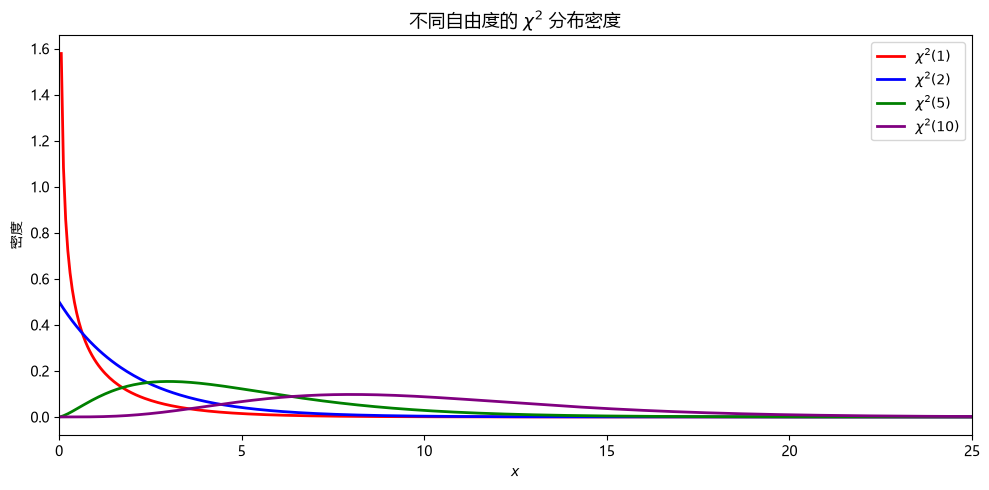

df=5: 均值=5.0, 方差=10.0
df=10: 均值=10.0, 方差=20.0


In [43]:
# === 代码演示：χ² 分布 ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

x = np.linspace(0, 30, 500)
fig, ax = plt.subplots(figsize=(10, 5))

for df, color in [(1, 'red'), (2, 'blue'), (5, 'green'), (10, 'purple')]:
    ax.plot(x, chi2.pdf(x, df), color=color, linewidth=2,
            label=f'$\\chi^2({df})$')

ax.set_title('不同自由度的 $\\chi^2$ 分布密度', fontsize=13)
ax.set_xlabel('$x$')
ax.set_ylabel('密度')
ax.legend()
ax.set_xlim(0, 25)
plt.tight_layout()
plt.show()

print(f"df=5: 均值={chi2.mean(5):.1f}, 方差={chi2.var(5):.1f}")
print(f"df=10: 均值={chi2.mean(10):.1f}, 方差={chi2.var(10):.1f}")


---


### 2.2.2 $t$ 分布


#### 定义


若 $U\sim N(0,1)$, $V\sim\chi^2(n)$,且 $U$ 与 $V$ 独立,则:


$$T=\frac{U}{\sqrt{V/n}}\sim t(n)$$


其中 $n$ 为自由度.


#### 密度函数


$$f_n(x)=\frac{\Gamma\!\bigl((n+1)/2\bigr)}{\sqrt{n\pi}\,\Gamma(n/2)}\left(1+\frac{x^2}{n}\right)^{-(n+1)/2},\qquad x\in\mathbb{R}$$


#### 性质


| 性质 | 内容 |
|:-----|:-----|
| **对称性** | $t$ 分布关于 $0$ 对称,密度函数是偶函数 |
| **期望** | $E(T)=0$($n>1$ 时存在) |
| **方差** | $D(T)=\dfrac{n}{n-2}$($n>2$ 时存在) |
| **极限** | $\displaystyle\lim_{n\to\infty}f_n(x)=\frac{1}{\sqrt{2\pi}}e^{-x^2/2}$,即收敛到标准正态 |

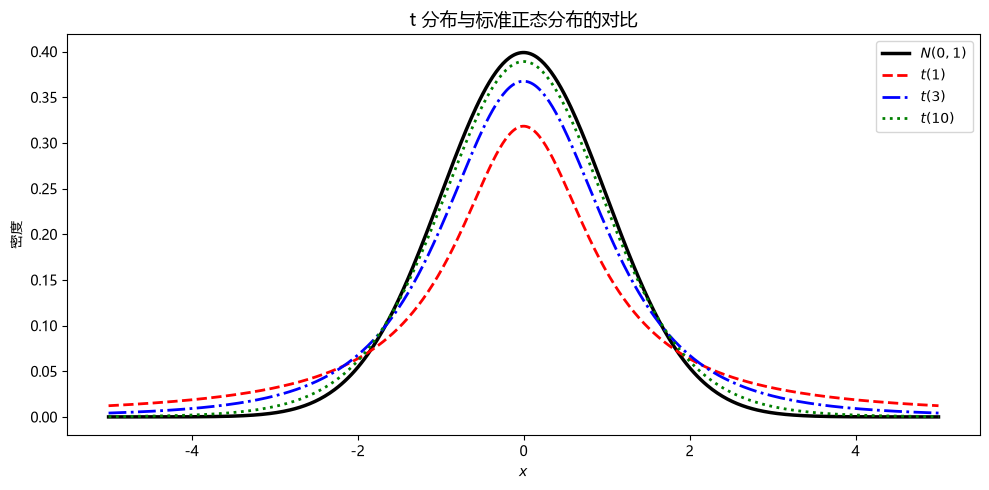

观察: 自由度较小时, t分布尾部更厚; 自由度增大时趋近于标准正态。


In [44]:
# === 代码演示：t 分布与标准正态的比较 ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

x = np.linspace(-5, 5, 500)
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x, norm.pdf(x), 'k-', linewidth=2.5, label='$N(0,1)$')
for df, color, style in [(1, 'red', '--'), (3, 'blue', '-.'), (10, 'green', ':')]:
    ax.plot(x, t.pdf(x, df), color=color, linestyle=style, linewidth=2,
            label=f'$t({df})$')

ax.set_title('t 分布与标准正态分布的对比', fontsize=13)
ax.set_xlabel('$x$')
ax.set_ylabel('密度')
ax.legend()
plt.tight_layout()
plt.show()

print("观察: 自由度较小时, t分布尾部更厚; 自由度增大时趋近于标准正态。")


---


### 2.2.3 $F$ 分布


#### 定义


若 $U\sim\chi^2(m)$, $V\sim\chi^2(n)$,且 $U$ 与 $V$ 独立,则:


$$F=\frac{U/m}{V/n}\sim F(m,n)$$


其中 $m$ 为 **第一自由度**,$n$ 为 **第二自由度**.


#### 倒数对称性


$$X\sim F(m,n)\quad\Longrightarrow\quad\frac1X\sim F(n,m)$$


#### $F(1,1)$ 的特殊性质


若 $X\sim F(1,1)$,则由对称性 $1/X\sim F(1,1)$,于是 $X$ 与 $1/X$ 同分布,故:


$$P\{|X|<1\}=P\{|1/X|>1\}=P\{|X|>1\}\quad\Rightarrow\quad P\{|X|<1\}=\frac12$$


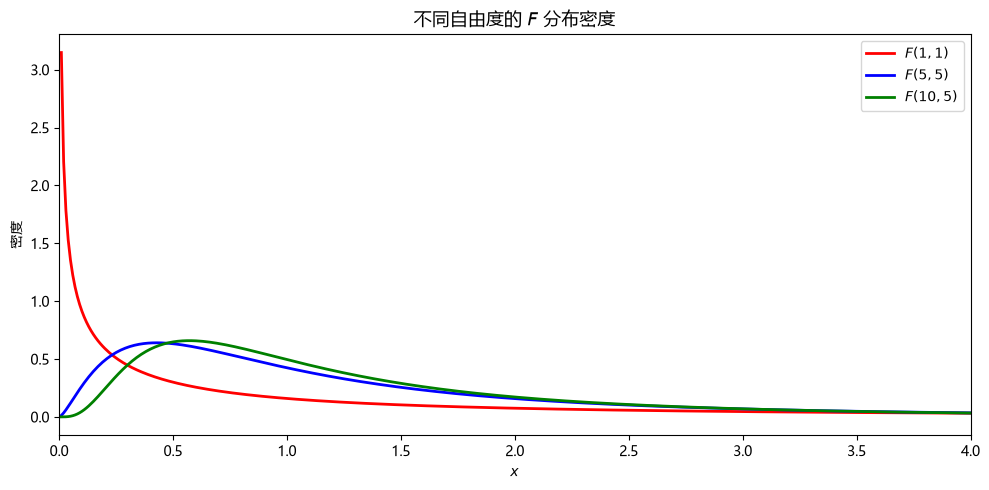

F(1,1) 的 P(X<1) = 0.5000 (理论: 0.5)


In [45]:
# === 代码演示：F 分布 ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

x = np.linspace(0, 5, 500)
fig, ax = plt.subplots(figsize=(10, 5))

for (m, n), color in [((1, 1), 'red'), ((5, 5), 'blue'), ((10, 5), 'green')]:
    ax.plot(x, f.pdf(x, m, n), color=color, linewidth=2,
            label=f'$F({m},{n})$')

ax.set_title('不同自由度的 $F$ 分布密度', fontsize=13)
ax.set_xlabel('$x$')
ax.set_ylabel('密度')
ax.legend()
ax.set_xlim(0, 4)
plt.tight_layout()
plt.show()

prob = f.cdf(1, 1, 1)
print(f"F(1,1) 的 P(X<1) = {prob:.4f} (理论: 0.5)")


---


### 2.2.4 三大分布之间的关系


```
N(0,1) ──平方──→ χ²(1) ──相除──→ F(1,n)
   │                           ↑
   │                           │
   └─────── 除以 √(χ²/n) ──────┘
                  │
                  ↓
               t(n) ──平方──→ F(1,n)
```


> $t$ 分布是标准正态与 $\chi^2$ 的组合,$F$ 分布是两个 $\chi^2$ 的比值.这三大分布构成了经典统计推断的支柱.


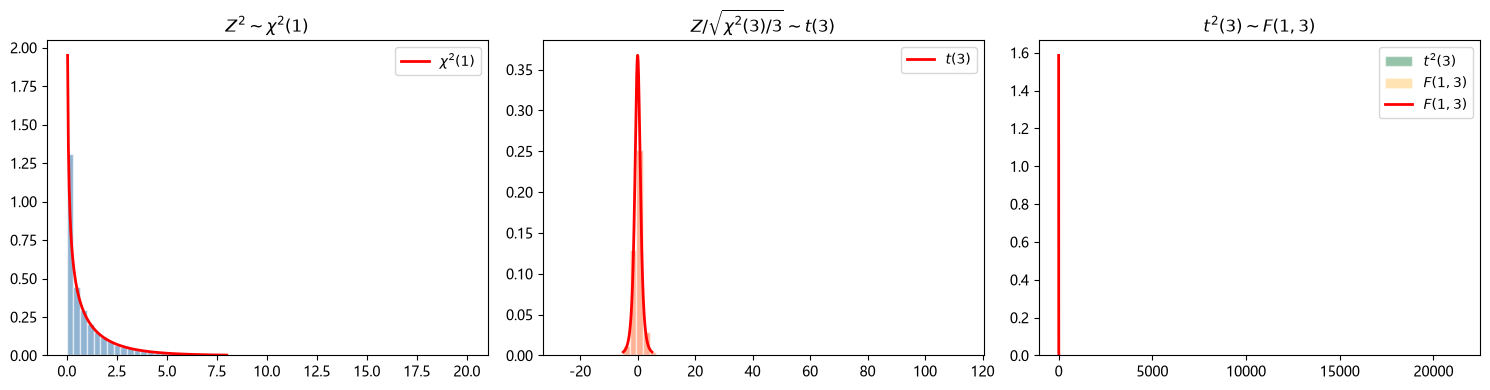

✅ 验证了三大分布之间的内在关系。


In [46]:
# === 代码演示：三大抽样分布的关系 ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2, t, f

np.random.seed(42)
n_sim = 100000

Z = np.random.normal(0, 1, n_sim)
Z2 = Z**2
chi2_3 = np.random.chisquare(3, n_sim)
T = Z / np.sqrt(chi2_3 / 3)
F_from_T = T**2
F_direct = np.random.f(1, 3, n_sim)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(Z2, bins=60, density=True, alpha=0.6, color='steelblue', edgecolor='white')
x1 = np.linspace(0, 8, 200)
axes[0].plot(x1, chi2.pdf(x1, 1), 'r-', linewidth=2, label='$\\chi^2(1)$')
axes[0].set_title('$Z^2 \\sim \\chi^2(1)$', fontsize=12)
axes[0].legend()

axes[1].hist(T, bins=60, density=True, alpha=0.6, color='coral', edgecolor='white')
x2 = np.linspace(-5, 5, 200)
axes[1].plot(x2, t.pdf(x2, 3), 'r-', linewidth=2, label='$t(3)$')
axes[1].set_title('$Z/\\sqrt{\\chi^2(3)/3} \\sim t(3)$', fontsize=12)
axes[1].legend()

axes[2].hist(F_from_T, bins=60, density=True, alpha=0.5, color='seagreen', edgecolor='white', label='$t^2(3)$')
axes[2].hist(F_direct, bins=60, density=True, alpha=0.3, color='orange', edgecolor='white', label='$F(1,3)$')
x3 = np.linspace(0, 10, 200)
axes[2].plot(x3, f.pdf(x3, 1, 3), 'r-', linewidth=2, label='$F(1,3)$')
axes[2].set_title('$t^2(3) \\sim F(1,3)$', fontsize=12)
axes[2].legend()

plt.tight_layout()
plt.show()
print("✅ 验证了三大分布之间的内在关系。")


---


### 2.2.5 构造 $\chi^2$, $t$, $F$ 的典型方法


给定独立 $N(0,1)$ 变量 $X_1,\cdots,X_5$:


> **$\chi^2$ 构造**:先线性组合、标准化,再平方求和


$$\frac1{14}(X_1-2X_2+3X_3)^2+\frac1{41}(4X_4-5X_5)^2\sim\chi^2(2)$$


> **$t$ 构造**:标准化后的分子除以 $\sqrt{\chi^2/df}$


$$\frac{\sqrt{2/3}\,(X_1+X_2+X_3)}{\sqrt{X_4^2+X_5^2}}\sim t(2)$$


> **$F$ 构造**:两个 $\chi^2$ 除以各自自由度后相比


$$\frac{(X_1^2+X_2^2+X_3^2)/3}{(X_4^2+X_5^2)/2}\sim F(3,2)$$


In [47]:
# === 代码演示：构造 χ², t, F 统计量 ===
import numpy as np
from scipy.stats import chi2, t, f

np.random.seed(42)
n_sim = 100000

X = np.random.normal(0, 1, (n_sim, 5))
X1, X2, X3, X4, X5 = X[:,0], X[:,1], X[:,2], X[:,3], X[:,4]

chi2_stat = (X1 - 2*X2 + 3*X3)**2 / 14 + (4*X4 - 5*X5)**2 / 41
t_stat = np.sqrt(2/3) * (X1 + X2 + X3) / np.sqrt(X4**2 + X5**2)
F_stat = ((X1**2 + X2**2 + X3**2) / 3) / ((X4**2 + X5**2) / 2)

print("构造统计量的分位数验证")
for alpha in [0.9, 0.95]:
    print(f'\\nalpha={alpha}:')
    print(f'  chi2(2) 构造: {np.quantile(chi2_stat, alpha):.3f}  (理论: {chi2.ppf(alpha, 2):.3f})')
    print(f'  t(2)  构造: {np.quantile(t_stat, alpha):.3f}  (理论: {t.ppf(alpha, 2):.3f})')
    print(f'  F(3,2)构造: {np.quantile(F_stat, alpha):.3f}  (理论: {f.ppf(alpha, 3, 2):.3f})')

print("\\n✅ 构造方法验证成功！")


构造统计量的分位数验证
\nalpha=0.9:
  chi2(2) 构造: 4.623  (理论: 4.605)
  t(2)  构造: 1.896  (理论: 1.886)
  F(3,2)构造: 9.114  (理论: 9.162)
\nalpha=0.95:
  chi2(2) 构造: 6.032  (理论: 5.991)
  t(2)  构造: 2.939  (理论: 2.920)
  F(3,2)构造: 19.208  (理论: 19.164)
\n✅ 构造方法验证成功！


---


### 2.2.6 Gamma 分布


#### 定义


$Ga(\alpha,\lambda)$ 的密度函数为:


$$f(x)=\begin{cases}\dfrac{\lambda^\alpha}{\Gamma(\alpha)}\,x^{\alpha-1}e^{-\lambda x}, & x>0,\\[8pt]0, & x\le0,\end{cases}\qquad\alpha>0,\ \lambda>0$$


#### 特征函数


$$\varphi(t)=\left(1-\frac{it}{\lambda}\right)^{-\alpha}$$


#### 矩


$$E(X^k)=\frac{\Gamma(\alpha+k)}{\Gamma(\alpha)}\cdot\frac{1}{\lambda^k}$$


特别地:


$$E(X)=\frac{\alpha}{\lambda},\qquad D(X)=\frac{\alpha}{\lambda^2}$$


#### 可加性


若 $X_i\sim Ga(\alpha_i,\lambda)$ 相互独立,则:


$$\sum_{i=1}^n X_i\sim Ga\!\left(\sum_{i=1}^n\alpha_i,\ \lambda\right)$$


> 证明利用特征函数:$\varphi_Y(t)=\prod\varphi_{X_i}(t)=(1-it/\lambda)^{-\sum\alpha_i}$.


#### 与 $\chi^2$ 分布的关系


$$\chi^2(n)=Ga\!\left(\frac{n}{2},\ \frac12\right)$$


#### 与指数分布的关系


$$E(\lambda)=Ga(1,\lambda)$$


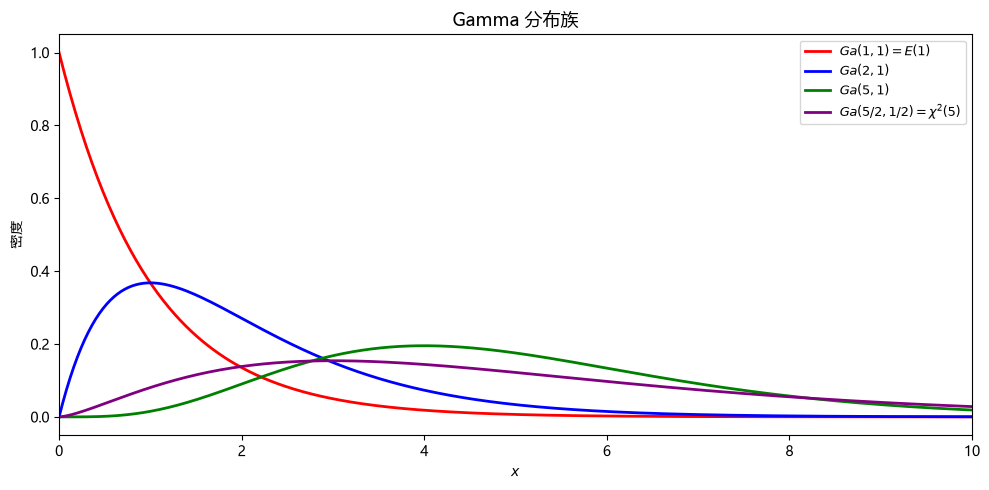

chi2(5) 在 x=3.0 处的密度: 0.1542
Ga(2.5, 1/2) 在 x=3.0 处的密度: 0.1542


In [48]:
# === 代码演示：Gamma 分布 ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, chi2

x = np.linspace(0, 10, 500)
fig, ax = plt.subplots(figsize=(10, 5))

for alpha, lam, color, label in [
    (1, 1, 'red', '$Ga(1,1)=E(1)$'),
    (2, 1, 'blue', '$Ga(2,1)$'),
    (5, 1, 'green', '$Ga(5,1)$'),
    (5/2, 1/2, 'purple', '$Ga(5/2,1/2)=\\chi^2(5)$')
]:
    ax.plot(x, gamma.pdf(x, a=alpha, scale=1/lam), color=color,
            linewidth=2, label=label)

ax.set_title('Gamma 分布族', fontsize=13)
ax.set_xlabel('$x$')
ax.set_ylabel('密度')
ax.legend(fontsize=9)
ax.set_xlim(0, 10)
plt.tight_layout()
plt.show()

n = 5
x_test = 3.0
print(f"chi2({n}) 在 x={x_test} 处的密度: {chi2.pdf(x_test, n):.4f}")
print(f"Ga({n/2}, 1/2) 在 x={x_test} 处的密度: {gamma.pdf(x_test, a=n/2, scale=2):.4f}")


---


### 2.2.7 概率积分变换


> **定理**:若总体 $X$ 的分布函数 $F(x)$ 严格单调递增连续,则


$$Y=F(X)\sim U(0,1)$$


**证明**:$P(Y\le y)=P(X\le F^{-1}(y))=F(F^{-1}(y))=y$.


**推论**:若 $Y_1,\cdots,Y_n$ 独立同分布于 $U(0,1)$,则


$$-2\sum_{i=1}^n\ln Y_i\sim\chi^2(2n)$$


这是因为 $-2\ln Y\sim\chi^2(2)$(指数分布 $E(1/2)$),再由 $\chi^2$ 的再生性得证.


> **💡 直观理解**:概率积分变换是将任意连续分布「拉直」为均匀分布的桥梁.


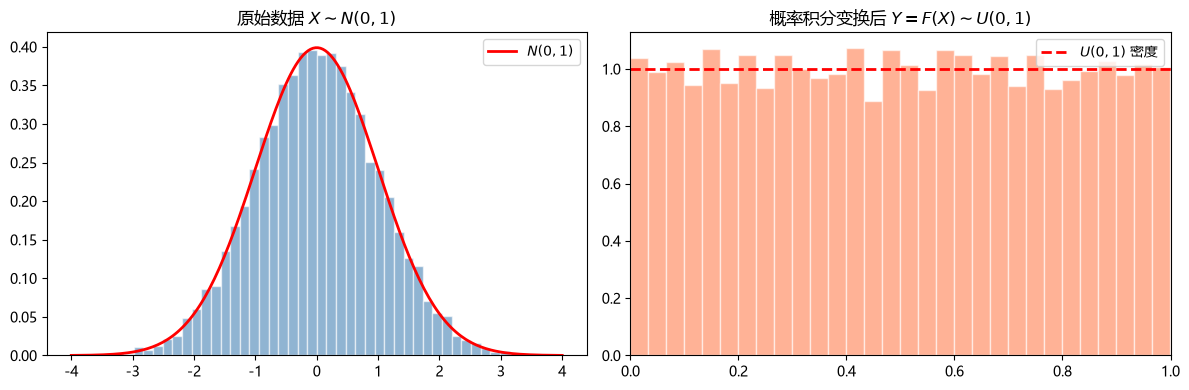

统计量均值: 9.98 (理论 chi2(10) 均值: 10)
统计量方差: 20.23 (理论 chi2(10) 方差: 20)
✅ 验证了概率积分变换的推论！


In [49]:
# === 代码演示：概率积分变换 ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2

np.random.seed(42)
n_sim = 10000

X = np.random.normal(0, 1, n_sim)
Y = norm.cdf(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='white')
x = np.linspace(-4, 4, 200)
axes[0].plot(x, norm.pdf(x), 'r-', linewidth=2, label='$N(0,1)$')
axes[0].set_title('原始数据 $X \\sim N(0,1)$', fontsize=12)
axes[0].legend()

axes[1].hist(Y, bins=30, density=True, alpha=0.6, color='coral', edgecolor='white')
axes[1].axhline(1, color='r', linestyle='--', linewidth=2, label='$U(0,1)$ 密度')
axes[1].set_title('概率积分变换后 $Y=F(X) \\sim U(0,1)$', fontsize=12)
axes[1].set_xlim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

n = 5
stat = np.zeros(n_sim)
for i in range(n_sim):
    Y_sample = np.random.uniform(0, 1, n)
    stat[i] = -2 * np.sum(np.log(Y_sample))

print(f"统计量均值: {np.mean(stat):.2f} (理论 chi2({2*n}) 均值: {2*n})")
print(f"统计量方差: {np.var(stat):.2f} (理论 chi2({2*n}) 方差: {4*n})")
print("✅ 验证了概率积分变换的推论！")


---


### 2.2.8 $\chi^2$ 变量之比与和的独立性


若 $X\sim\chi^2(m)$, $Y\sim\chi^2(n)$ 独立,则 $U=X/Y$ 与 $V=X+Y$ 相互独立.


> 证明利用 **Jacobian 变换**:联合密度经变换后恰好分解为 $g(u)h(v)$ 的形式.


---


## 2.3 样本矩


### 2.3.1 样本均值与样本方差


$$\overline{X}=\frac{1}{n}\sum_{i=1}^n X_i,\qquad S^2=\frac{1}{n-1}\sum_{i=1}^n (X_i-\overline{X})^2$$


> **注**:分母用 $n-1$ 而非 $n$,是为了使 $S^2$ 成为 $\sigma^2$ 的无偏估计.


### 2.3.2 Poisson 总体的样本矩


总体 $P(\lambda)$:$EX=\lambda$, $DX=\lambda$


$$\begin{aligned}E\overline{X} &= \lambda, & D\overline{X} &= \frac{\lambda}{n}, & ES^2 &= \lambda\end{aligned}$$


### 2.3.3 正态总体的样本矩


总体 $N(\mu,\sigma^2)$:$EX=\mu$, $DX=\sigma^2$


$$\begin{aligned}E\overline{X} &= \mu, & D\overline{X} &= \frac{\sigma^2}{n}, & ES^2 &= \sigma^2\end{aligned}$$


进一步,由抽样分布定理:$\displaystyle\frac{(n-1)S^2}{\sigma^2}\sim\chi^2(n-1)$,故


$$DS^2 = \frac{2\sigma^4}{n-1}$$


C:\Users\18904\AppData\Local\Temp\ipykernel_28732\309579476.py:31: UserWarning: Glyph 88 (X) missing from font(s) Microsoft YaHei.
  plt.tight_layout()


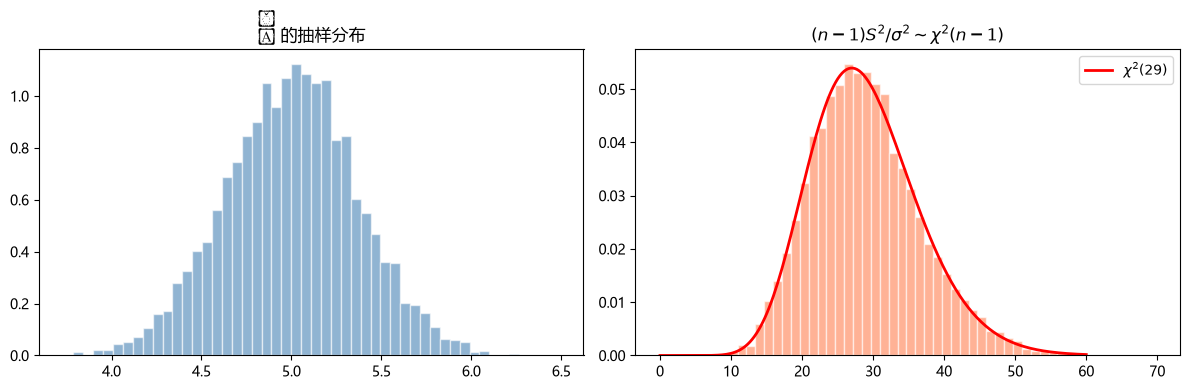

X̄ 的模拟均值: 5.000 (理论: 5)
S² 的模拟均值: 3.997 (理论: 4)


In [50]:
# === 代码演示：样本均值与样本方差的抽样分布 ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

np.random.seed(42)

mu, sigma = 5, 2
n = 30
n_sim = 10000

Xbar = np.zeros(n_sim)
S2 = np.zeros(n_sim)

for i in range(n_sim):
    sample = np.random.normal(mu, sigma, n)
    Xbar[i] = np.mean(sample)
    S2[i] = np.var(sample, ddof=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(Xbar, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='white')
axes[0].set_title('X̄ 的抽样分布', fontsize=12)

axes[1].hist((n-1)*S2/sigma**2, bins=50, density=True, alpha=0.6, color='coral', edgecolor='white')
x2 = np.linspace(0, 60, 200)
axes[1].plot(x2, chi2.pdf(x2, n-1), 'r-', linewidth=2, label=f'$\\chi^2({n-1})$')
axes[1].set_title('$(n-1)S^2/\\sigma^2 \\sim \\chi^2(n-1)$', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"X̄ 的模拟均值: {np.mean(Xbar):.3f} (理论: {mu})")
print(f"S² 的模拟均值: {np.mean(S2):.3f} (理论: {sigma**2})")


---


### 2.3.4 构造含样本均值和样本方差的抽样分布


> **构造 $t$ 分布**


利用 $X_{n+1}-\overline{X}\sim N(0,\frac{n+1}{n}\sigma^2)$ 和 $\overline{X}$ 与 $S_n^2$ 的独立性:


$$\frac{X_{n+1}-\overline{X}}{S_n\sqrt{(n+1)/(n-1)}}\sim t(n-1)$$


其中 $S_n^2=\frac1n\sum(X_i-\overline{X})^2$.


> **构造 $\chi^2$ 分布**


令 $a=n/\sigma^2$, $b=(n-1)/\sigma^2$,由 $\chi^2$ 的再生性:


$$a(\overline{X}-\mu)^2+bS^2\sim\chi^2(n)$$


> **构造 $F$ 分布**


$$\frac{m\sum_{i=1}^n X_i^2}{n\sum_{i=n+1}^{m+n}X_i^2}\sim F(n,m)$$


> **构造 $F(1,1)$ 并验证独立性**


$$\left(\frac{X_1+X_2}{X_1-X_2}\right)^2\sim F(1,1)$$


验证 $X_1+X_2$ 与 $X_1-X_2$ 独立:用 **协方差的双线性性** 计算 $\text{Cov}(X_1+X_2,X_1-X_2)=D(X_1)-D(X_2)=0$,正态分布下不相关等价于独立.


In [51]:
# === 代码演示：构造含 X̄ 和 S² 的 t 分布 ===
import numpy as np
from scipy.stats import t as t_dist

np.random.seed(42)
n = 10
n_sim = 50000

t_stats = np.zeros(n_sim)
for i in range(n_sim):
    X = np.random.normal(0, 1, n+1)
    X_bar = np.mean(X[:n])
    Sn2 = np.var(X[:n], ddof=0)
    t_stats[i] = (X[n] - X_bar) / (np.sqrt(Sn2) * np.sqrt((n+1)/(n-1)))

print(f"构造统计量的 0.95 分位数: {np.quantile(t_stats, 0.95):.3f}")
print(f"理论 t({n-1}) 的 0.95 分位数: {t_dist.ppf(0.95, n-1):.3f}")
print("✅ 构造的 t 分布统计量验证成功。")


构造统计量的 0.95 分位数: 1.847
理论 t(9) 的 0.95 分位数: 1.833
✅ 构造的 t 分布统计量验证成功。
